# 01 — Chuẩn bị MVTec AD trên Kaggle

Notebook của **giai đoạn 1**: kiểm tra dữ liệu, tạo split cố định và xuất báo cáo. Chưa train model.

**Input:** dataset `/kaggle/input/datasets/ipythonx/mvtec-ad` và bundle package của repo.
**Output:** `/kaggle/working/visual-ad`, gồm manifest, fingerprint, thống kê và ảnh/mask minh họa.

Trong Kaggle: Add Input dataset MVTec AD và bundle private đã tạo bằng `scripts/build_kaggle_bundle.py`. Giai đoạn này chạy CPU được. Bật Internet để cài dependency; nếu chạy offline, cần chuẩn bị wheelhouse riêng trước.

`Save & Run All` chạy lại từ đầu; lưu phiên có output trước khi dùng manifest ở notebook huấn luyện.

## 1. Cài đúng package và kiểm tra bundle

Wheel chứa logic của repo; notebook không sao chép thuật toán chia tập. Kiểm tra checksum giúp phát hiện file bundle bị thay đổi. Hash là kiểm tra toàn vẹn, không phải chữ ký xác thực nguồn.

Sửa `BUNDLE_ROOT` nếu mount Kaggle của bundle khác. Chế độ `USE_INSTALLED_PACKAGE` chỉ phục vụ kiểm thử local với môi trường đã khóa.

In [2]:
import hashlib
import json
import os
from pathlib import Path
import subprocess
import sys

BUNDLE_ROOT = Path(os.environ.get('VAD_BUNDLE_ROOT', '/kaggle/input/datasets/vnnhhiu/visual-ad-phase1-v1'))
USE_INSTALLED_PACKAGE = os.environ.get('VAD_USE_INSTALLED_PACKAGE') == '1'
assert (3, 11) <= sys.version_info[:2] < (3, 13), 'Package hỗ trợ Python 3.11 hoặc 3.12'
if not USE_INSTALLED_PACKAGE:
    provenance = json.loads((BUNDLE_ROOT / 'bundle-manifest.json').read_text())
    for relative, expected in provenance['files'].items():
        path = (BUNDLE_ROOT / relative).resolve()
        assert path.is_relative_to(BUNDLE_ROOT.resolve()), 'Path ngoài bundle'
        actual = hashlib.sha256(path.read_bytes()).hexdigest()
        assert actual == expected, f'Checksum sai: {relative}'
    wheels = list(BUNDLE_ROOT.glob('visual_ad_lab-*.whl'))
    assert len(wheels) == 1, 'Bundle phải có đúng một wheel visual-ad-lab'
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(BUNDLE_ROOT / 'requirements-kaggle.lock')], check=True)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '--no-deps', '--force-reinstall', str(wheels[0])], check=True)

from visual_ad.common import environment, source_hash
if not USE_INSTALLED_PACKAGE:
    assert source_hash() == provenance['source_fingerprint'], 'Source đang import khác bundle; restart session'
print(json.dumps(environment(), indent=2))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 1.2 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.15.0
    Uninstalling typing_extensions-4.15.0:
      Successfully uninstalled typing_extensions-4.15.0
  Attempting uninstall: annotated-types
    Found existing installation: annotated-types 0.7.0
    Uninstalling annotated-types-0.7.0:
      Successfully uninstalled annotated-types-0.7.0
  Attempting uninstall: typing-inspection
    Found existing installation: typing-inspection 0.4.2
    Uninstalling typing-inspection-0.4.2:
      Successfully uninstalled typing-inspection-0.4.2


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


Processing /kaggle/input/datasets/vnnhhiu/visual-ad-phase1-v1/visual_ad_lab-0.1.0-py3-none-any.whl
{
  "python": "3.12.13",
  "platform": "Linux-6.12.90+-x86_64-with-glibc2.35",
  "cpu": "x86_64",
  "versions": {
    "visual-ad-lab": "0.1.0",
    "anomalib": null,
    "torch": "2.10.0+cpu",
    "torchvision": "0.25.0+cpu",
    "lightning": null,
    "numpy": "2.0.2",
    "pillow": "11.3.0",
    "pydantic": "2.12.3",
    "pyyaml": "6.0.3",
    "scipy": "1.16.3",
    "scikit-learn": "1.6.1"
  }
}


## 2. Cấu hình và đường dẫn

Dữ liệu input chỉ được đọc; output phải nằm ngoài dataset. Seed 42 điều khiển việc chia tập. `require_all_categories=True` là mặc định cho dữ liệu thật.

Tỷ lệ split thuộc protocol có version: normal 70/15/15, test 40/60. Thay protocol sẽ cần phiên bản mới để tránh trộn kết quả.

In [3]:
from visual_ad.config import load_config
from visual_ad.data import resolve_root

config_path = BUNDLE_ROOT / 'configs' / 'data.yaml'
config = load_config(config_path if config_path.exists() else None,
    data_root=os.environ.get('VAD_DATA_ROOT'),
    output_root=os.environ.get('VAD_OUTPUT_ROOT'))
DATA_ROOT = resolve_root(config.data_root)
OUTPUT_ROOT = config.output_root
print('Dataset root:', DATA_ROOT)
print('Output root:', OUTPUT_ROOT)
print(config.model_dump(mode='json'))

Dataset root: /kaggle/input/datasets/ipythonx/mvtec-ad
Output root: /kaggle/working/visual-ad
{'schema_version': 1, 'data_root': '/kaggle/input/datasets/ipythonx/mvtec-ad', 'output_root': '/kaggle/working/visual-ad', 'dataset_name': 'mvtec-ad', 'dataset_version': 'kaggle-ipythonx-local-content-hash', 'seed': 42, 'require_all_categories': True, 'image_size': 256}


## 3. Kiểm tra dữ liệu và tạo manifest

Lệnh này decode ảnh, kiểm tra ảnh trùng, mask rỗng/sai kích thước, hash dữ liệu và chia từng nhóm category/defect type. Nếu có lỗi, phải xử lý nguyên nhân trước khi tiếp tục; không bỏ qua sample lỗi.

Train normal: phần fit học model, validation hỗ trợ training, calibration dùng chọn threshold ở giai đoạn sau. Selection chọn phương pháp; final test được giữ độc lập.

Lần chạy lại chỉ chấp nhận manifest và cấu hình giống lần đầu. Muốn thay cấu hình hãy dùng output directory mới.

In [4]:
from visual_ad.cli import main

arguments = ['data', 'prepare', '--root', str(DATA_ROOT), '--output', str(OUTPUT_ROOT), '--seed', str(config.seed)]
if config_path.exists():
    arguments += ['--config', str(config_path)]
status = main(arguments)
assert status == 0, 'Chuẩn bị dữ liệu thất bại; đọc thông báo lỗi/last-status.json trước khi tiếp tục'

{
  "schema_version": 1,
  "generated_at": "2026-09-10T05:24:55.496882+00:00",
  "status": "data_validated",
  "execution_location": "kaggle",
  "dataset_name": "mvtec-ad",
  "dataset_version": "kaggle-ipythonx-local-content-hash",
  "dataset_fingerprint": "061f3c21830a4d837464311b4dd06f2538174fd46dd7f1efd7ed431f3bcd73a1",
  "split_fingerprint": "c3e88882c2e2df4283373ecaa9c7f4cc3ec7eb99e9201cf493f3e1f0902e6ff9",
  "config_hash": "c53f510b4ff11cc52525e01c43ede567975ccd6f35aa4b01aa8252f0683c34e9",
  "seed": 42,
  "source_fingerprint": "dbdba4a5c82ea6ae9c468a5125192924cbb0cc2d209ea7c6c99d01b0148b01f1",
  "environment": {
    "python": "3.12.13",
    "platform": "Linux-6.12.90+-x86_64-with-glibc2.35",
    "cpu": "x86_64",
    "versions": {
      "visual-ad-lab": "0.1.0",
      "anomalib": null,
      "torch": "2.10.0+cpu",
      "torchvision": "0.25.0+cpu",
      "lightning": null,
      "numpy": "2.0.2",
      "pillow": "11.3.0",
      "pydantic": "2.12.3",
      "pyyaml": "6.0.3",
      

## 4. Đọc báo cáo và kiểm tra trực quan

Mỗi hàng ảnh minh họa gồm **ảnh gốc — ground-truth mask — overlay**. Gallery chỉ dùng fit/selection, không mở ảnh final_test để tránh chỉnh thiết kế theo holdout.

Đối chiếu số lượng từng category. Nhóm lỗi chỉ có một ảnh sẽ được đưa vào final_test và ghi cảnh báo; một số metric có thể không xác định nếu thiếu lớp.

Số ảnh: 5354
Số category: 15
Split fingerprint: c3e88882c2e2df4283373ecaa9c7f4cc3ec7eb99e9201cf493f3e1f0902e6ff9
Cảnh báo: []


# Báo cáo kiểm tra dữ liệu — giai đoạn 1

Sinh lúc: 2026-09-10T05:24:55.496882+00:00. Môi trường: kaggle.

Đã kiểm tra 5354 ảnh thuộc 15 category.
Đây là bằng chứng kiểm tra dữ liệu được truyền vào lệnh; không phải kết quả huấn luyện.

## Thiết kế và lý do

Adapter giữ đường dẫn tương đối để chuyển dữ liệu giữa Kaggle/local mà không đổi sample ID.
Train normal được chia fit/validation/calibration; test gốc được chia selection/final_test.
Việc giữ final_test độc lập cho phép kiểm chứng lựa chọn mô hình ở giai đoạn sau.

## Fingerprint và tái lập

- Dataset: `061f3c21830a4d837464311b4dd06f2538174fd46dd7f1efd7ed431f3bcd73a1`
- Split: `c3e88882c2e2df4283373ecaa9c7f4cc3ec7eb99e9201cf493f3e1f0902e6ff9`
- Seed: `42`
- Source: `dbdba4a5c82ea6ae9c468a5125192924cbb0cc2d209ea7c6c99d01b0148b01f1`

Xem `resolved-config.json`, `inventory.json`, `split-manifest.json` và `data-report.json` cùng thư mục.

## Số mẫu sau chia tập

- bottle: fit=147, validation_normal=31, calibration_normal=31, selection=32, final_test=51
- cable: fit=158, validation_normal=33, calibration_normal=33, selection=57, final_test=93
- capsule: fit=155, validation_normal=32, calibration_normal=32, selection=51, final_test=81
- carpet: fit=196, validation_normal=42, calibration_normal=42, selection=43, final_test=74
- grid: fit=186, validation_normal=39, calibration_normal=39, selection=28, final_test=50
- hazelnut: fit=275, validation_normal=58, calibration_normal=58, selection=42, final_test=68
- leather: fit=173, validation_normal=36, calibration_normal=36, selection=46, final_test=78
- metal_nut: fit=154, validation_normal=33, calibration_normal=33, selection=44, final_test=71
- pill: fit=187, validation_normal=40, calibration_normal=40, selection=63, final_test=104
- screw: fit=224, validation_normal=48, calibration_normal=48, selection=62, final_test=98
- tile: fit=162, validation_normal=34, calibration_normal=34, selection=45, final_test=72
- toothbrush: fit=42, validation_normal=9, calibration_normal=9, selection=16, final_test=26
- transistor: fit=151, validation_normal=31, calibration_normal=31, selection=40, final_test=60
- wood: fit=173, validation_normal=37, calibration_normal=37, selection=30, final_test=49
- zipper: fit=168, validation_normal=36, calibration_normal=36, selection=56, final_test=95

## Kiểm chứng

Đã decode ảnh, kiểm tra mask nhị phân/cùng kích thước, ảnh trùng, fingerprint và vai trò split.
Đọc số lượng từng category trong `split-counts.csv`; không suy diễn rằng mọi loại lỗi có đủ mẫu.

## Cảnh báo và giới hạn

Không phát hiện cảnh báo chia tập.

Kiểm tra duplicate chỉ phát hiện ảnh trùng pixel; chưa phát hiện near-duplicate hoặc cùng vật thể vật lý.
Chưa huấn luyện, calibration threshold hay đo metric mô hình.

## Kiểm tra trực quan

![Ảnh gốc, mask, overlay](data-preview.png)

Mỗi hàng: ảnh gốc — mask — overlay. Chỉ xem fit/selection.

## Tự kiểm tra

1. Vì sao đổi data root không đổi fingerprint? Vì hash dùng đường dẫn tương đối và nội dung.
2. Vì sao không xem final_test trong gallery? Để tránh chỉnh thiết kế dựa trên holdout.
3. Vì sao mask dùng nearest-neighbor? Để giữ nhãn rời rạc khi resize.

## Bước tiếp theo

Lưu output thành Kaggle Notebook Version, kiểm tra cảnh báo, rồi dùng manifest này cho evaluator và adapter mô hình.


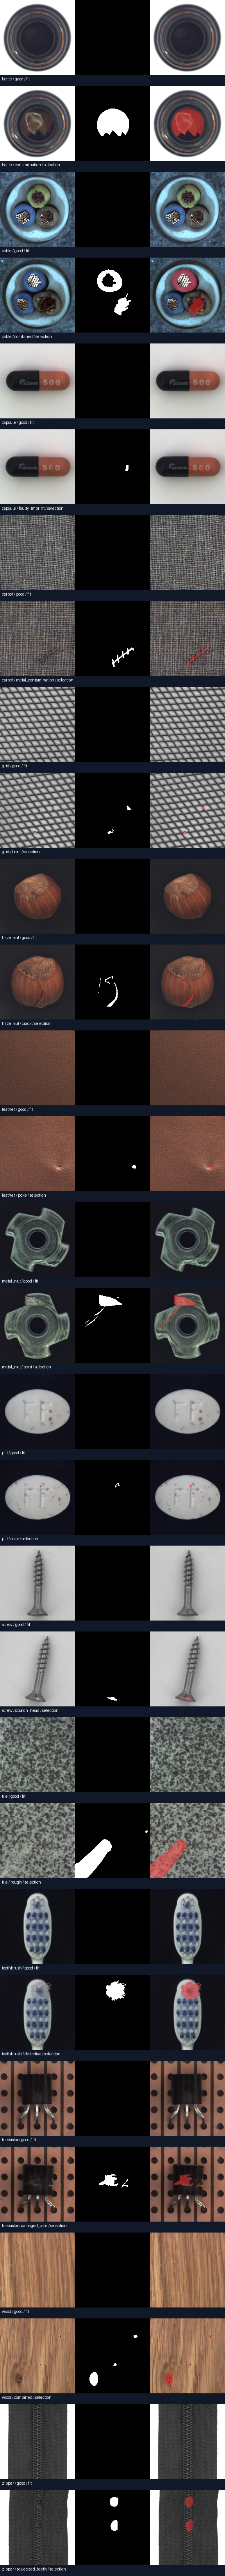

In [5]:
from IPython.display import Markdown, Image as DisplayImage, display
from visual_ad.common import read_json

report = read_json(OUTPUT_ROOT / 'data-report.json')
print('Số ảnh:', report['sample_count'])
print('Số category:', report['category_count'])
print('Split fingerprint:', report['split_fingerprint'])
print('Cảnh báo:', report['warnings'])
display(Markdown((OUTPUT_ROOT / 'data-report.md').read_text()))
display(DisplayImage(filename=str(OUTPUT_ROOT / 'data-preview.png')))

## 5. Kiểm tra canonical sample

Đầu ra adapter là RGB `float32 [C,H,W]` trong `[0,1]`; mask `bool [H,W]`. Chưa ImageNet-normalize vì từng model có preprocessing riêng. Resize mask dùng nearest-neighbor để không sinh nhãn trung gian.

In [6]:
from visual_ad.data import load_manifest, load_sample, samples_for

manifest = load_manifest(OUTPUT_ROOT / 'split-manifest.json')
row = samples_for(manifest, manifest['categories'][0], 'fit')[0]
sample = load_sample(DATA_ROOT, row, config.image_size)
print('image:', sample['image'].shape, sample['image'].dtype)
print('mask:', sample['mask'].shape, sample['mask'].dtype)
print('original_size:', sample['original_size'])
assert not sample['mask'].any(), 'Fit sample normal phải có mask toàn 0'

image: (3, 256, 256) float32
mask: (256, 256) bool
original_size: [900, 900]


## 6. Đóng gói, tải kết quả và chuyển giai đoạn

Sau khi kiểm tra gallery/cảnh báo, cell tiếp theo tạo một ZIP ở `/kaggle/working`. ZIP chỉ chứa bằng chứng cần thiết, không chứa ảnh dataset. `checksums.json` bên trong giúp kiểm tra file sau khi tải.

Các file được đóng gói:
- `inventory.json`, `split-manifest.json`: dữ liệu và phân chia có fingerprint.
- `resolved-config.json`, `last-status.json`: cấu hình và trạng thái lần chạy.
- `data-report.md`, `data-report.json`, `split-counts.csv`, `samples.csv`, `data-preview.png`: bằng chứng kiểm tra.
- `checksums.json`: SHA-256 của từng file cùng dataset/split fingerprint.

Tên ZIP có 12 ký tự đầu của split fingerprint để phân biệt các lần chia. Sau khi tải ZIP, vẫn lưu Notebook Version chứa output để Kaggle có thể dùng trực tiếp ở notebook huấn luyện.

**Tự kiểm tra:** vì sao chỉ seed thôi chưa đủ để tái lập? Vì còn cần cùng dữ liệu, protocol và phiên bản code. Vì sao không thay root trong manifest? Manifest lưu đường dẫn tương đối nên có thể chuyển máy mà giữ danh tính sample.

In [7]:
from IPython.display import FileLink, display
from visual_ad.reporting import archive_phase1_results

archive_info = archive_phase1_results(OUTPUT_ROOT)
print(json.dumps(archive_info, ensure_ascii=False, indent=2))
display(FileLink(archive_info['archive'], result_html_prefix='Tải ZIP kết quả: '))

{
  "archive": "/kaggle/working/visual-ad-phase1-c3e88882c2e2.zip",
  "size_bytes": 3081834,
  "file_count": 10,
  "split_fingerprint": "c3e88882c2e2df4283373ecaa9c7f4cc3ec7eb99e9201cf493f3e1f0902e6ff9"
}


/kaggle/working/visual-ad-phase1-c3e88882c2e2.zip